# Esercizio: Discretizzazione di Eulero e Metodo Monte Carlo

## 1. Il Problema Continuo
Consideriamo l'equazione differenziale stocastica 1-dimensionale espressa dalla dinamica:
$$dX_t = b(t, X_t)dt + \sigma(t, X_t)dW_t, \quad X_0 = x_0$$

Nel caso specifico dell'esercizio, l'equazione è definita per $t \in [0, 1]$ con i seguenti dati:
* coefficiente di drift: $b(t, x) = t(1 - x)$
* coefficiente di diffusione: $\sigma(t, x) = \sqrt{t|x|}$
* condizione iniziale: $X_0 = 1$
  
L'equazione differenziale stocastica assume pertanto la forma:
$$\Large dX_t = t(1 - X_t)dt + \sqrt{t|X_t|}dW_t$$


## 2. Discretizzazione Temporale dell'Intervallo
Prendiamo l'intervallo continuo $[0, T]$ e lo andiamo a discretizzare in $n-1$ sotto-intervalli equispaziati (si ha un passo di discretizzazione costante). Definendo $\Delta t$ come l'ampiezza costante di ciascun sotto-intervallo e denotando con $n$ il numero totale dei nodi temporali discreti generati sulla griglia, definiamo i nodi come:
$$t_i = i \Delta t \quad \text{per } i = 0, 1, \dots, n-1$$


## 3. Simulazione della Traiettoria: Il Metodo di Eulero
Il nostro obiettivo ora è simulare il campionamento della traiettoria valutandola esclusivamente in questi specifici istanti di tempo $t_i$. 
Usiamo il metodo di Eulero, che consiste nell'approssimare le variazioni infinitesimali con variazioni finite sulla nostra griglia discreta:
* Il differenziale temporale viene approssimato dall'ampiezza dell'intervallo: $dt \approx \Delta t = t_{i+1} - t_i$
* Il differenziale del processo diventa la differenza tra i due stati: $dX_t \approx \Delta X_i = X_{t_{i+1}} - X_{t_i}$
* Il differenziale del moto Browniano diventa: $dW_t \approx \Delta W_i = W_{t_{i+1}} - W_{t_i}$

Per le proprietà del processo di Wiener, l'incremento browniano è indipendente dalla storia passata e distribuito normalmente, quindi può essere simulato estraendo una variabile casuale normale standard $Z_i \sim \mathcal{N}(0, 1)$ moltiplicata per la radice del passo temporale:
$$\Delta W_i = Z_i \sqrt{\Delta t}$$

Sostituendo queste approssimazioni discrete all'interno della dinamica continua di partenza, si ottiene:
$$\Delta X_i = t_i(1 - X_{t_i})\Delta t + \sqrt{t_i|X_{t_i}|}\Delta W_i$$
Partendo da $X_{t_i}$, è possibile calcolare lo stato al passo successivo $X_{t_{i+1}}$ tramite la formula ricorsiva:
$$\Large X_{t_{i+1}} = X_{t_i} + t_i(1 - X_{t_i})\Delta t + \sqrt{t_i|X_{t_i}|}\Delta W_i$$


## 4. Stima del Valore Atteso
L'obiettivo è calcolare numericamente il valore atteso del payoff al tempo terminale $T = 1$:
$$\mathbb{E}\left[ \max\{0, 2 - (X_1)^2\} \right]$$

Usando il metodo Monte Carlo con un numero elevato $M$ di traiettorie stocastiche, approssimiamo il valore atteso con la media aritmetica:
$$\mathbb{E}\left[ \max\{0, 2 - (X_1)^2\} \right] \approx \frac{1}{M} \sum_{i=1}^{M} \max\left\{0, 2 - \left(X_N^{(i)}\right)^2\right\}$$

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import time

In [2]:
#Parametri del modello
X0 = 1.0          # Condizione iniziale del processo 
T = 1.0           # Orizzonte temporale dell'esperimento
m = 100000      # Numero di traiettorie di Monte Carlo
delta_t = 1.0 / 252  # Passo di discretizzazione temporale

In [3]:
# Generazione dell'asse dei tempi. Viene aggiunto un fattore di tolleranza '1e-10'per garantire che il valore finale T=1 
# sia incluso nell'intervallo
tt = np.arange(start=0, stop=T + 1e-10, step=delta_t)
n = len(tt)     # Numero di nodi temporali 

In [4]:
print("Verifica della discretizzazione temporale")
print("-" * 50)
print(f"Ampiezza del passo (Delta t) : {delta_t:.6f} (ovvero 1/252)")
print(f"Numero totale di NODI (n)    : {n}")
print(f"Numero di INTERVALLI (n - 1) : {n - 1}")
print(f"Primo istante temporale t_0: {tt[0]:.2f}")
print(f"Ultimo istante temporale     : {tt[-1]:.2f}")
print("-" * 50)

Verifica della discretizzazione temporale
--------------------------------------------------
Ampiezza del passo (Delta t) : 0.003968 (ovvero 1/252)
Numero totale di NODI (n)    : 253
Numero di INTERVALLI (n - 1) : 252
Primo istante temporale t_0: 0.00
Ultimo istante temporale     : 1.00
--------------------------------------------------


In [5]:
X = np.zeros(shape=(n,m)) # Allocazione di memoria, dove n (il numero di righe) rappresenta il numero di 
                          # nodi temporali e m rappresenta il numero di simulazioni

X[0,:] = X0               # Condizione iniziale: assegniamo il valore X0 alla prima riga (tempo t=0)
                          # per tutte le m traiettorie contemporaneamente

In [6]:
X

array([[1., 1., 1., ..., 1., 1., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [7]:
for i in range(n-1):
    dW = stats.norm.rvs(size=m) * np.sqrt(delta_t)
    X[i+1,:] = X[i,:] + tt[i]*(1-X[i,:])*delta_t + np.sqrt(tt[i]*np.abs(X[i,:]))*dW

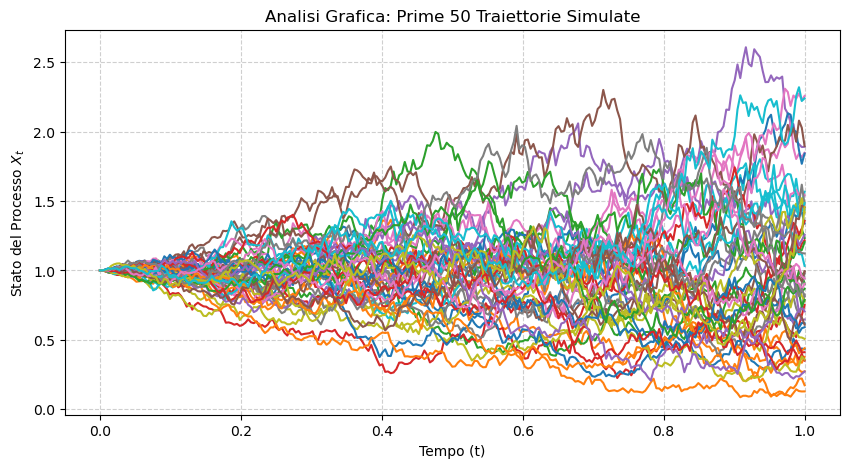

In [8]:
# Filtriamo la matrice tramite slicing prendendo tutte le righe del tempo, ma solo le prime 50 colonne.
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(tt, X[:, 0:50]) 
ax.set_title("Analisi Grafica: Prime 50 Traiettorie Simulate")
ax.set_xlabel("Tempo (t)")
ax.set_ylabel("Stato del Processo $X_t$")
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [9]:
# Valutazione del payoff su tutti gli scenari simulati e calcolo della media finale
payoff = (2 - (X[n-1, :])**2).clip(min=0)

valore_atteso_stimato = payoff.mean()

print(f"La stima Monte Carlo del valore atteso è pari a: {valore_atteso_stimato:.3f}")

La stima Monte Carlo del valore atteso è pari a: 1.014
